## Feature Visualization

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from torchvision.models import resnet50, ResNet50_Weights, inception_v3, Inception_V3_Weights

In [3]:
# weights = ResNet50_Weights.DEFAULT
weights = Inception_V3_Weights.DEFAULT

preprocess = weights.transforms()

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# resnet = resnet50(weights=weights)
inception = inception_v3(weights=weights).to(device)

In [4]:
# resnet.eval()
inception.eval()

Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [5]:
weights.meta["categories"]

['tench',
 'goldfish',
 'great white shark',
 'tiger shark',
 'hammerhead',
 'electric ray',
 'stingray',
 'cock',
 'hen',
 'ostrich',
 'brambling',
 'goldfinch',
 'house finch',
 'junco',
 'indigo bunting',
 'robin',
 'bulbul',
 'jay',
 'magpie',
 'chickadee',
 'water ouzel',
 'kite',
 'bald eagle',
 'vulture',
 'great grey owl',
 'European fire salamander',
 'common newt',
 'eft',
 'spotted salamander',
 'axolotl',
 'bullfrog',
 'tree frog',
 'tailed frog',
 'loggerhead',
 'leatherback turtle',
 'mud turtle',
 'terrapin',
 'box turtle',
 'banded gecko',
 'common iguana',
 'American chameleon',
 'whiptail',
 'agama',
 'frilled lizard',
 'alligator lizard',
 'Gila monster',
 'green lizard',
 'African chameleon',
 'Komodo dragon',
 'African crocodile',
 'American alligator',
 'triceratops',
 'thunder snake',
 'ringneck snake',
 'hognose snake',
 'green snake',
 'king snake',
 'garter snake',
 'water snake',
 'vine snake',
 'night snake',
 'boa constrictor',
 'rock python',
 'Indian cobr

In [56]:
saved_tensors = []

def hook(module, input, output):
    saved_tensors.append(output)

# inception.Conv2d_3b_1x1.register_forward_hook(hook)
inception.Mixed_6d.register_forward_hook(hook)
# inception.Mixed_7c.register_forward_hook(hook)

In [55]:
inception.Conv2d_3b_1x1._forward_hooks.clear()
inception.Mixed_6d._forward_hooks.clear()
inception.Mixed_7c._forward_hooks.clear()

In [90]:
import torchvision.transforms.functional as TF

def total_variation_loss(img, weight):
     bs_img, c_img, h_img, w_img = img.size()
     tv_h = torch.pow(img[:,:,1:,:]-img[:,:,:-1,:], 2).sum()
     tv_w = torch.pow(img[:,:,:,1:]-img[:,:,:,:-1], 2).sum()
     return weight*(tv_h+tv_w)/(bs_img*c_img*h_img*w_img)

def blur_loss(img, sigma=1.0):
    # Penalize high frequencies by encouraging smoothness
    blurred_image = TF.gaussian_blur(img, kernel_size=[5, 5], sigma=[1.0, 1.0])
    return sigma*torch.nn.functional.mse_loss(img, blurred_image)

In [128]:
eps = torch.nn.Parameter(preprocess(torch.randn(1, 3, 224, 224) * 0.1 + 0.5).to(device))
saved_tensors = []

max_i = 20

epochs = 2000

optim = torch.optim.Adam([eps], lr=0.1, maximize=True)
scheduler = torch.optim.lr_scheduler.LinearLR(optim, 0.8, 1.0, epochs)

# lam_tv = 0.09
lam_decay = 0.01
lam_blur = 0.1

for i in range(epochs):

    # pred = resnet(eps).squeeze(0).softmax(0)
    pred = inception(eps).squeeze(0).softmax(0)

    optim.zero_grad()

    # (1, C, H, W)
    feature = saved_tensors[-1][:, max_i:max_i+1].mean()

    act = feature - lam_decay*eps.norm() - blur_loss(eps, lam_blur) # - total_variation_loss(eps, lam_tv)

    act.backward(torch.ones_like(feature))

    optim.step()
    scheduler.step()

    np_pred = pred.detach().cpu().numpy()
    idx = np.argsort(np_pred)[::-1]

    print(i, saved_tensors[-1][:, max_i].sum().item(), {weights.meta["categories"][i]: np_pred[i] for i in idx[:5]})

0 52.6947021484375 {'kite': 0.025545716, 'ballpoint': 0.022922115, 'nematode': 0.020763816, 'switch': 0.019072484, 'necklace': 0.018080771}
1 127.48391723632812 {'jersey': 0.1353249, 'handkerchief': 0.07261614, 'plastic bag': 0.056003485, 'envelope': 0.055667546, 'apron': 0.04161159}
2 286.53167724609375 {'envelope': 0.07976949, 'handkerchief': 0.060207978, 'tray': 0.037974395, 'binder': 0.037738338, 'jersey': 0.035606585}
3 462.6316223144531 {'bib': 0.23664662, 'bath towel': 0.06589787, 'binder': 0.05489028, 'apron': 0.047231726, 'shower curtain': 0.034398388}
4 636.5936889648438 {'bib': 0.2891214, 'teapot': 0.085235566, 'apron': 0.048386548, 'mixing bowl': 0.02225901, 'pitcher': 0.020198511}
5 777.7236328125 {'teapot': 0.14589977, 'pitcher': 0.1421579, 'bib': 0.06885902, 'mixing bowl': 0.044049453, 'cup': 0.033892218}
6 906.8836669921875 {'pitcher': 0.044483684, 'spider web': 0.03518592, 'teapot': 0.03011532, 'bib': 0.022131642, 'goblet': 0.01613209}
7 1006.5322265625 {'pitcher': 0.1

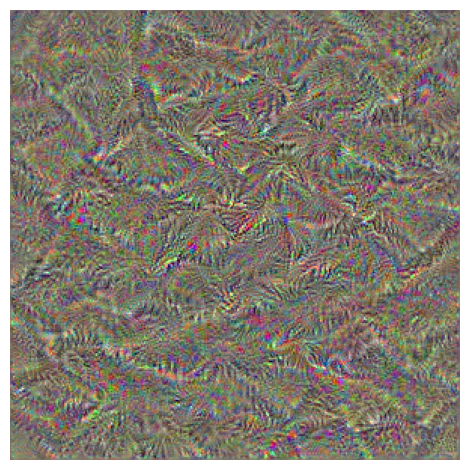

In [127]:
# for reference: torchvision uses this normalization scheme
# normalize = Normalize(mean=[0.485, 0.456, 0.406],
#                         std=[0.229, 0.224, 0.225])
std = np.array([0.229, 0.224, 0.225]).reshape(1, 1, -1)
mean = np.array([0.485, 0.456, 0.406]).reshape(1, 1, -1)

np_noise = (eps).detach().cpu().squeeze().permute(1, 2, 0).numpy()
normalized_img = np.clip(((np_noise * std) + mean), 0, 1)

plt.imshow(normalized_img)
plt.axis('off')

plt.tight_layout()
plt.show()


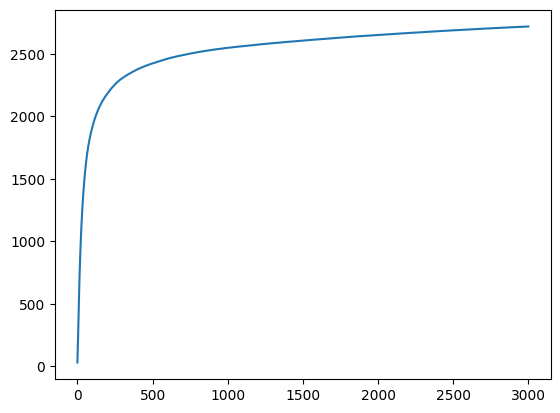

In [124]:
plt.plot([s[:, max_i].sum().item() for s in saved_tensors])

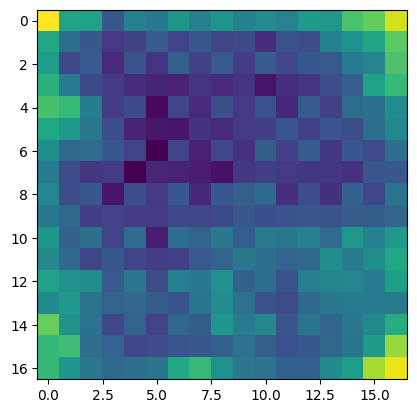

In [125]:
plt.imshow(saved_tensors[-1].squeeze().cpu().detach().numpy().mean(0))